## Section 1: Imports & Configuration

In [6]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
 
import yfinance as yf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from itertools import product

In [7]:
# Configuration
TEST_SIZE = 60            # Hold-out test set (days)
FORECAST_HORIZON = 5      # Days to forecast into the future
RANDOM_STATE = 42

## Section 2: Data Acquisition & EDA
Download historical OHLCV data via yfinance and perform exploratory analysis.

In [42]:
import kagglehub
import os

path = kagglehub.dataset_download("umerhaddii/apple-stock-data-2025")
print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/umerhaddii/apple-stock-data-2025/versions/1


['apple_stock.csv']

In [43]:
data = pd.read_csv(path + '/apple_stock.csv')
print(data.shape)
data.head()
type(data)

(11107, 7)


pandas.DataFrame

In [44]:
data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data = data[data['Date'].dt.year >= 2006]
data = data.reset_index(drop=True)
data = data.set_index('Date')
data.columns = [col.lower().replace(' ', '_') for col in data.columns]
data.index = pd.to_datetime(data.index)
data


,adj_close,close,high,low,open,volume
Date,,,,,,
2006-01-03,2.251970,2.669643,2.669643,2.580357,2.585000,807234400
2006-01-04,2.258598,2.677500,2.713571,2.660714,2.683214,619603600
2006-01-05,2.240824,2.656429,2.675000,2.633929,2.672500,449422400
2006-01-06,2.298666,2.725000,2.739286,2.662500,2.687500,704457600
2006-01-09,2.291134,2.716071,2.757143,2.705000,2.740357,675040800
...,...,...,...,...,...,...
2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700


In [45]:
df = data[['close']].rename(columns={'close': 'Close'})
df.head()

,Close
Date,
2006-01-03,2.669643
2006-01-04,2.677500
2006-01-05,2.656429
2006-01-06,2.725000
2006-01-09,2.716071


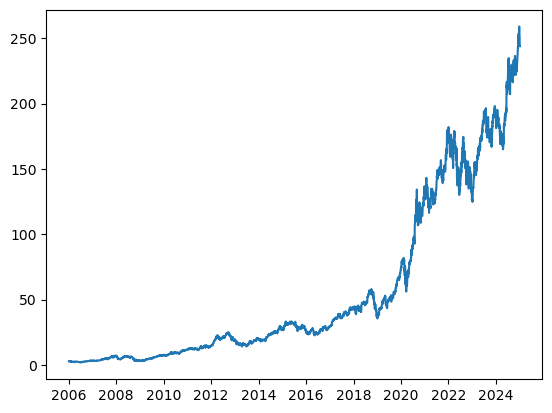

In [46]:
plt.plot(df.index, df.Close)
plt.show()

In [51]:
data = data[data.index.year >= 2015].reset_index()
data = data.set_index('Date')
df = data[['close']].rename(columns={'close': 'Close'})

print(f"Dataset: {df.shape[0]} trading days  |  {df.index.min().date()} → {df.index.max().date()}")
print(df.describe())

Dataset: 2518 trading days  |  2015-01-02 → 2025-01-03
             Close
count  2518.000000
mean     96.481120
std      65.361557
min      22.584999
25%      37.650624
50%      66.752502
75%     152.929996
max     259.019989


EDA: Closing price + 30-day rolling statistics

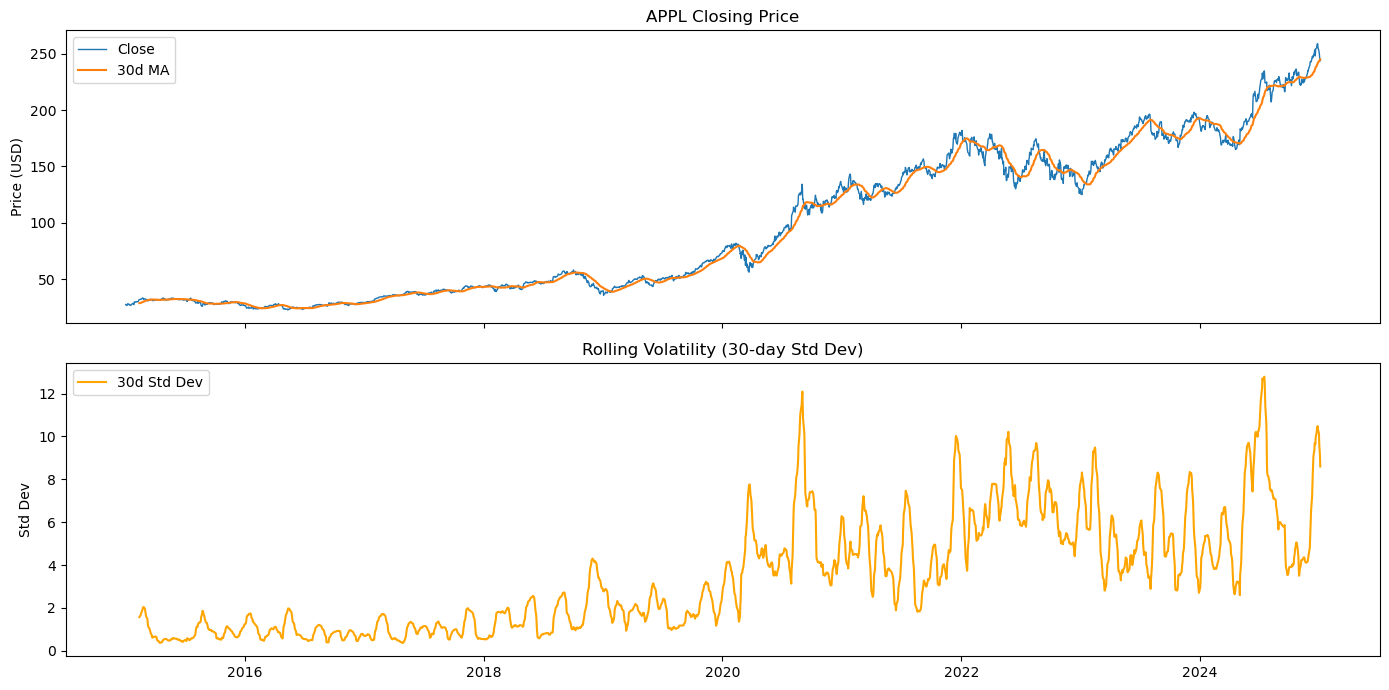

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
 
axes[0].plot(df["Close"], label="Close", linewidth=1)
axes[0].plot(df["Close"].rolling(30).mean(), label="30d MA", linewidth=1.5)
axes[0].set_title(f"APPL Closing Price")
axes[0].legend()
axes[0].set_ylabel("Price (USD)")
 
axes[1].plot(df["Close"].rolling(30).std(), color="orange", label="30d Std Dev")
axes[1].set_title("Rolling Volatility (30-day Std Dev)")
axes[1].legend()
axes[1].set_ylabel("Std Dev")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
plt.tight_layout()
plt.savefig("eda_price.png", dpi=150)
plt.show()

Daily returns distribution

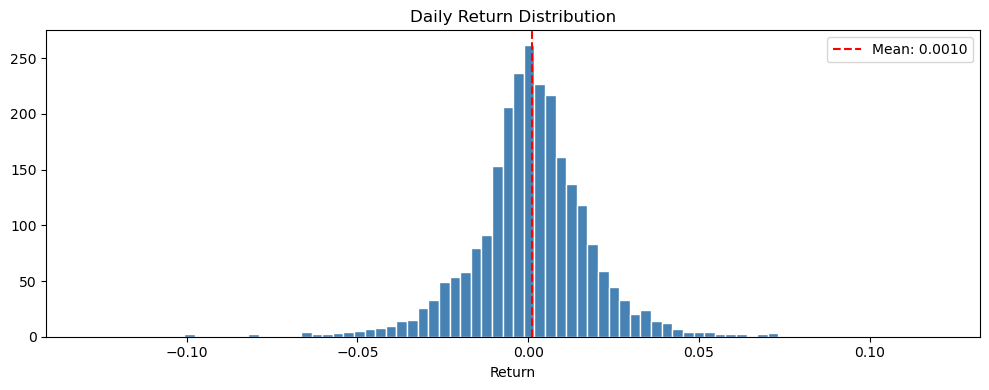

In [54]:
returns = df["Close"].pct_change().dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(returns, bins=80, edgecolor="white", color="steelblue")
ax.axvline(returns.mean(), color="red", linestyle="--", label=f"Mean: {returns.mean():.4f}")
ax.set_title("Daily Return Distribution")
ax.set_xlabel("Return")
ax.legend()
plt.tight_layout()
plt.savefig("eda_returns.png", dpi=150)
plt.show()

## Section 3: Stationarity Testing (ADF)
The Augmented Dickey-Fuller test checks for a unit root.
H0: series has a unit root (non-stationary).
If p-value < 0.05, we reject H0 → series is stationary.

In [58]:
def adf_test(series, label="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test — {label}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Stationary     : {'YES' if result[1] < 0.05 else 'NO'}")
    return result[1] < 0.05
 
is_stationary = adf_test(df["Close"], label="Close Price")
 
# First-difference if non-stationary
df["Close_diff"] = df["Close"].diff()
adf_test(df["Close_diff"].dropna(), label="First-Differenced Close")


ADF Test — Close Price
  Test Statistic : 0.5635
  p-value        : 0.9867
  Lags Used      : 0
  Stationary     : NO

ADF Test — First-Differenced Close
  Test Statistic : -15.7944
  p-value        : 0.0000
  Lags Used      : 9
  Stationary     : YES


np.True_

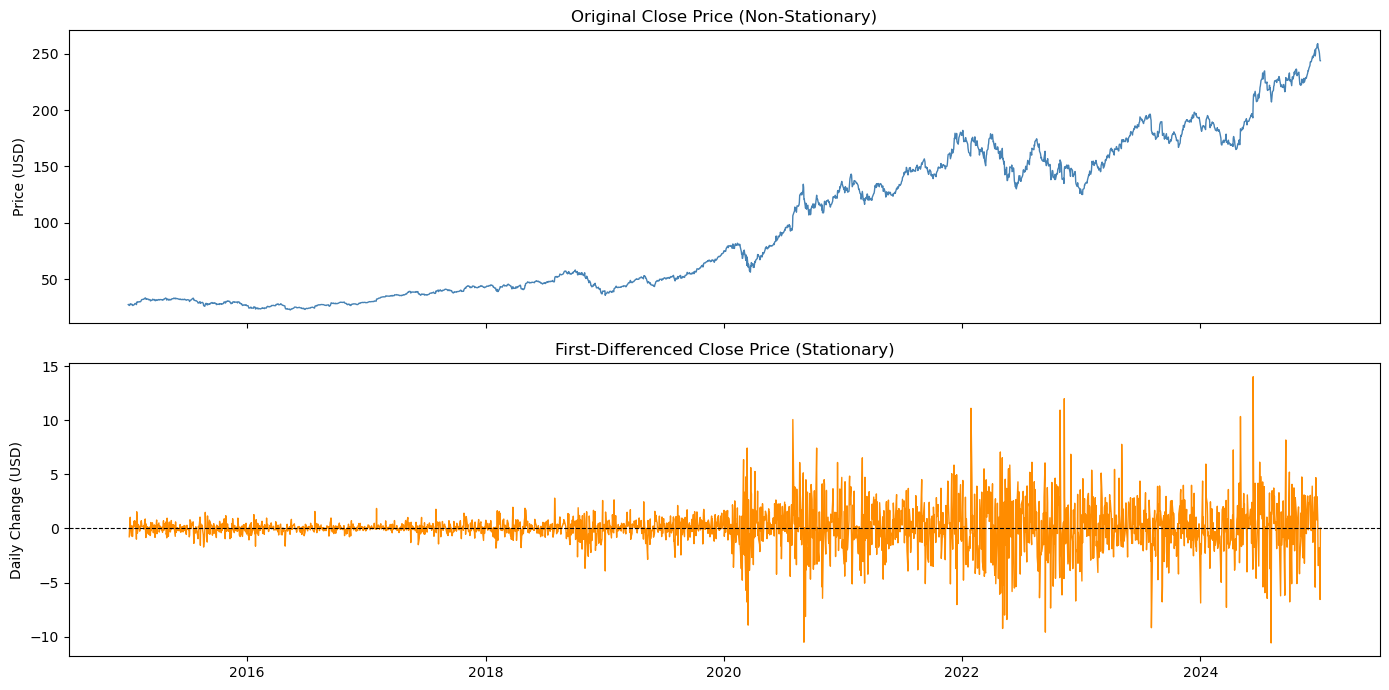

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["Close"], linewidth=1, color="steelblue")
axes[0].set_title("Original Close Price (Non-Stationary)")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df["Close"].diff(), linewidth=1, color="darkorange")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("First-Differenced Close Price (Stationary)")
axes[1].set_ylabel("Daily Change (USD)")

plt.tight_layout()
plt.show()

## Section 4: ACF / PACF Plots
Used to determine ARIMA (p, d, q) parameters.
- PACF cuts off at lag p → AR order
- ACF cuts off at lag q → MA order

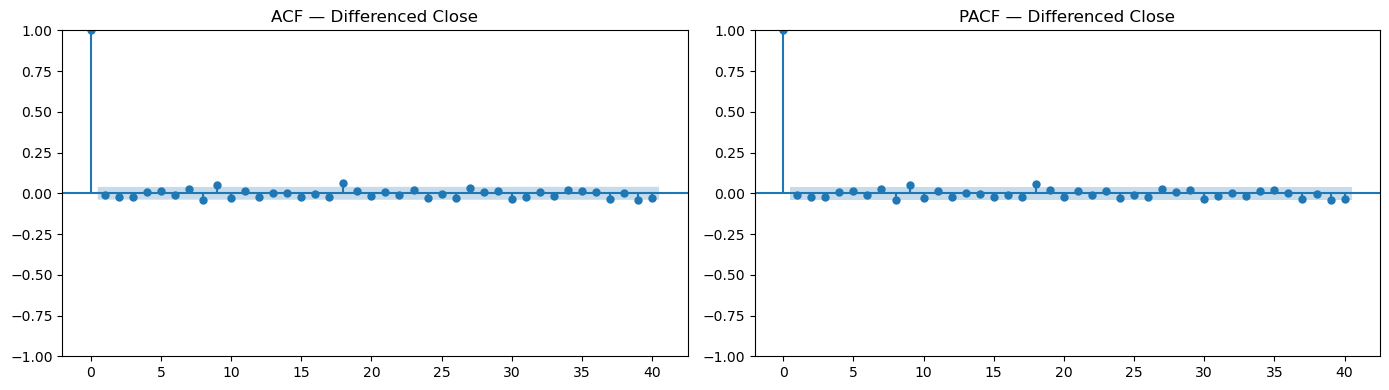

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Close_diff"].dropna(), lags=40, ax=axes[0], title="ACF — Differenced Close")
plot_pacf(df["Close_diff"].dropna(), lags=40, ax=axes[1], title="PACF — Differenced Close")
plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=150)
plt.show()

## Section 5: Train/Test Split

Train: 2458 observations  |  Test: 60 observations


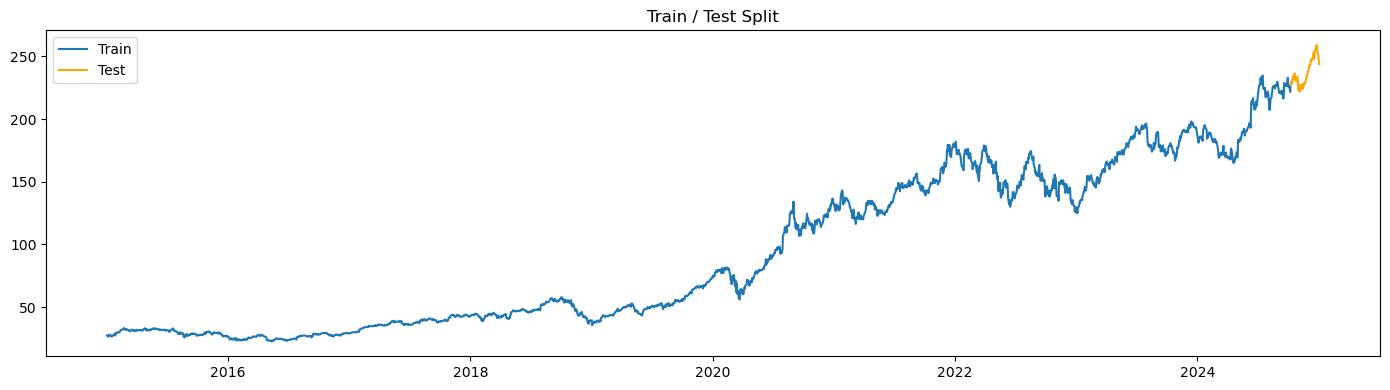

In [60]:
train = df["Close"].iloc[:-TEST_SIZE]
test  = df["Close"].iloc[-TEST_SIZE:]
 
print(f"Train: {len(train)} observations  |  Test: {len(test)} observations")
 
plt.figure(figsize=(14, 4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test", color="orange")
plt.title("Train / Test Split")
plt.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150)
plt.show()

## Section 6: SARIMAX Model
SARIMAX(p, d, q)(P, D, Q, s) — adds seasonal components on top of ARIMA.
A lightweight grid search is run over p, q, P, Q to minimise AIC.

In [62]:
def sarimax_grid_search(train_series, p_range=(0,3), q_range=(0,3), P_range=(0,2), Q_range=(0,2), d=1, D=1, s=5):
    """Simple AIC-based grid search for SARIMAX order."""
    best_aic = np.inf
    best_order = None
    best_seasonal = None
 
    combos = list(product(range(*p_range), range(*q_range), range(*P_range), range(*Q_range)))
    print(f"Testing {len(combos)} SARIMAX configurations…")
 
    for p, q, P, Q in combos:
        try:
            model = SARIMAX(train_series,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
                best_seasonal = (P, D, Q, s)
        except Exception:
            continue
 
    print(f"Best order: {best_order}  |  Seasonal: {best_seasonal}  |  AIC: {best_aic:.2f}")
    return best_order, best_seasonal

sarimax_order, sarimax_seasonal = sarimax_grid_search(train)

Testing 36 SARIMAX configurations…
Best order: (0, 1, 2)  |  Seasonal: (0, 1, 1, 5)  |  AIC: 10234.60


Fit final SARIMAX and generate test-set predictions

In [63]:
sarimax_model = SARIMAX(train,
                        order=sarimax_order,
                        seasonal_order=sarimax_seasonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
 
print(sarimax_model.summary())
 
sarimax_pred = sarimax_model.forecast(steps=TEST_SIZE)
sarimax_pred.index = test.index

                                      SARIMAX Results                                      
Dep. Variable:                               Close   No. Observations:                 2458
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 5)   Log Likelihood               -5113.299
Date:                             Wed, 29 Apr 2026   AIC                          10234.599
Time:                                     23:33:52   BIC                          10257.804
Sample:                                          0   HQIC                         10243.033
                                            - 2458                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0229      0.013     -1.802      0.072      -0.048       0.002
ma.L2         -0.0211      